Importing

Importing csv as pandas dataframe.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

df = pd.read_csv("diabetes_dataset.csv")

Parsing

Some things to clean: boundary conditions for ldl_cholesterol and insulin_level.

In [24]:
df = df.dropna()

Organizing

We are choosing which columns to use and cleaning these columns.

Columns we are dropping: diagnosed_diabetes


In [25]:
diabetes_stage_detectors_df = list(df.groupby('diabetes_stage')[['ldl_cholesterol', 'insulin_level', 'hba1c', 'waist_to_hip_ratio']])

smoking_df = df[['smoking_status', 'diabetes_stage']]

average_df = df.groupby('diagnosed_diabetes')[['diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'alcohol_consumption_per_week']]

Doing consecutive ANOVA tests to see if any diabetes stages have an effect on the following values: ldl cholesterol, insulin levle, hba1c, and waist to hip ratio.

In [26]:
# storing dataframes by diabetes stage
gestational = diabetes_stage_detectors_df[0][1]
no_diabetes = diabetes_stage_detectors_df[1][1]
pre_diabetes = diabetes_stage_detectors_df[2][1]
type1 = diabetes_stage_detectors_df[3][1]
type2 = diabetes_stage_detectors_df[4][1]

Testing ldl cholesterol:

H0 = Diabetes Stage has no effect on ldl cholesterol values

HA = Diabetes Stage has a significant effect on ldl cholesterol values

1.2028061964524944e-129

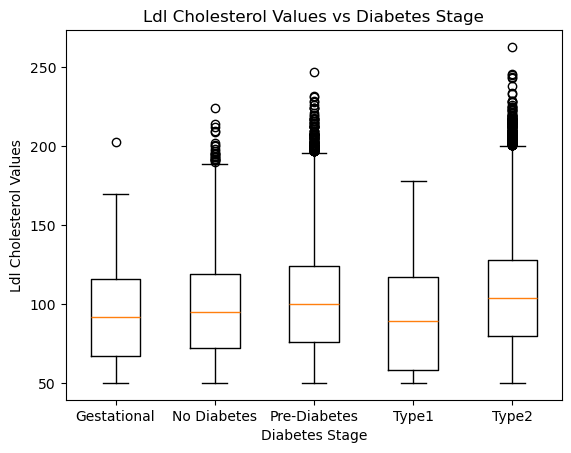

In [37]:
ldl_gestational = gestational['ldl_cholesterol']
ldl_no_diabetes = no_diabetes['ldl_cholesterol']
ldl_pre_diabetes = pre_diabetes['ldl_cholesterol']
ldl_type1 = type1['ldl_cholesterol']
ldl_type2 = type2['ldl_cholesterol']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2)
display(res.pvalue.item())

plt.boxplot([ldl_gestational, ldl_no_diabetes, ldl_pre_diabetes, ldl_type1, ldl_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Ldl Cholesterol Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Ldl Cholesterol Values")
plt.show()

We note the excessive circles representing outliers. We propose that the cause of so many outliers is due to the large sample size (). 

The p-value of the ANOVA test is significantly low, meaning at least one of the diabetes stages has different ldl cholesterol values than the others.

0        160
2         99
3         79
4        125
7        159
        ... 
99990     90
99991     97
99992    140
99993    109
99994     57
Name: ldl_cholesterol, Length: 59774, dtype: int64

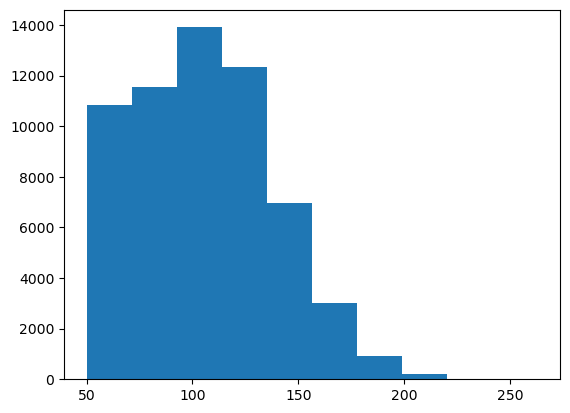

In [38]:
display(ldl_type2)
plt.hist(ldl_type2)
plt.show()

Testing insulin level:

H0 = Diabetes Stage has no effect on insulin level values

HA = Diabetes Stage has a significant effect on insulin level values

7.272269779528698e-88

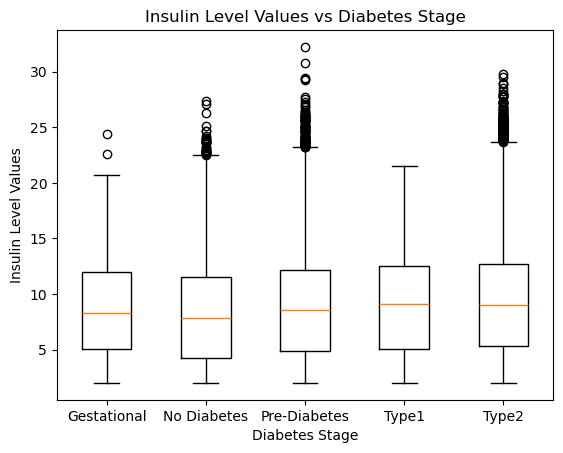

In [32]:
insulin_gestational = gestational['insulin_level']
insulin_no_diabetes = no_diabetes['insulin_level']
insulin_pre_diabetes = pre_diabetes['insulin_level']
insulin_type1 = type1['insulin_level']
insulin_type2 = type2['insulin_level']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2)
display(res.pvalue.item())

plt.boxplot([insulin_gestational, insulin_no_diabetes, insulin_pre_diabetes, insulin_type1, insulin_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Insulin Level Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Insulin Level Values")
plt.show()

Testing hba1c:

H0 = Diabetes Stage has no effect on hba1c values

HA = Diabetes Stage has a significant effect on hba1c values

0.0

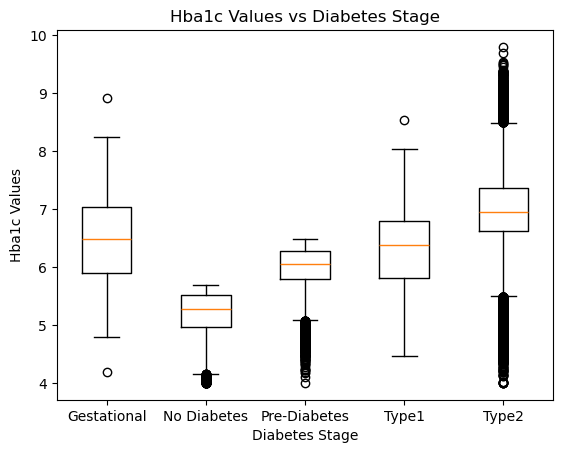

In [29]:
hba1c_gestational = gestational['hba1c']
hba1c_no_diabetes = no_diabetes['hba1c']
hba1c_pre_diabetes = pre_diabetes['hba1c']
hba1c_type1 = type1['hba1c']
hba1c_type2 = type2['hba1c']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2)
display(res.pvalue.item())

plt.boxplot([hba1c_gestational, hba1c_no_diabetes, hba1c_pre_diabetes, hba1c_type1, hba1c_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Hba1c Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Hba1c Values")
plt.show()

Testing waist to hip ratio:

H0 = Diabetes Stage has no effect on waist to hip ratio values

HA = Diabetes Stage has a significant effect on waist to hip ratio values

1.2436844935656955e-167

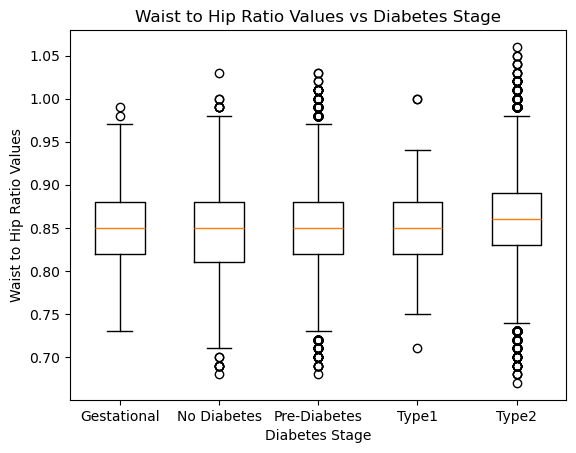

In [30]:
whr_gestational = gestational['waist_to_hip_ratio']
whr_no_diabetes = no_diabetes['waist_to_hip_ratio']
whr_pre_diabetes = pre_diabetes['waist_to_hip_ratio']
whr_type1 = type1['waist_to_hip_ratio']
whr_type2 = type2['waist_to_hip_ratio']

# Chose ANOVA as there are 3 groups of independent data that we are comparing
# the means of to see if there is any significant difference
res = stats.f_oneway(whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2)
display(res.pvalue.item())

plt.boxplot([whr_gestational, whr_no_diabetes, whr_pre_diabetes, whr_type1, whr_type2], tick_labels=["Gestational", "No Diabetes", "Pre-Diabetes", "Type1", "Type2"])

# plt.legend()
plt.title("Waist to Hip Ratio Values vs Diabetes Stage")
plt.xlabel("Diabetes Stage")
plt.ylabel("Waist to Hip Ratio Values")
plt.show()